# Random Forest

## Import libraries

In [1]:
import ccxt
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

In [2]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

Y_OUTPUT_DICT = {
    "log_return_close": False,
    "bin_return_close": True,
    "bin_return_d2d_close": True,
}

In [3]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
TIMEFRAME = "1h"
LAGS_NUM = 240
TRAIN_TEST_SPLIT_RATIO = 0.7
N_ESTIMATORS = 300
MAX_DEPTH = 8
MIN_SAMPLES_LEAF = 5
MAX_FEATURES = "sqrt"
RANDOM_STATE = 42
N_JOBS = -1
OUTPUT_VALUE = 'bin_return_d2d_close'
BINARY_CLASSIFICATION = Y_OUTPUT_DICT[OUTPUT_VALUE]

## Fetching data

In [4]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=1000,
        )
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [5]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035


### Verifying continuous of data

In [6]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)   # 0 => none missing dates

0 DatetimeIndex([], dtype='datetime64[ms]', freq='h')


## Processing data

In [7]:
data['log_return_close'] = np.log(data['Close'] / data['Close'].shift(1))
data['return_close'] = data['Close'] / data['Close'].shift(1) - 1
data['bin_return_close'] = (data['log_return_close'] > 0).astype(int)
data['bin_return_d2d_close'] = (data['log_return_close'] > data['log_return_close'].shift(1)).astype(int)

In [8]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,,,,,
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031,0.000203,0.000203,1,0
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337,0.000786,0.000786,1,1
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032,0.002556,0.002560,1,1
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035,-0.000580,-0.000580,0,0
2023-11-04 01:00:00,34696.66,34786.68,34632.47,34768.15,724.86868,0.002059,0.002061,1,1


## Splitting data

In [9]:
def prepare_lagged_dataset(data, lags_num, output_value):
    dataset = pd.DataFrame(index=data.index)
    for lag in range(1, lags_num + 1):
        dataset[f"lag_{lag}"] = data["log_return_close"].shift(lag)
    dataset["target"] = data[output_value]
    dataset["return_close"] = data["return_close"]
    dataset = dataset.dropna()
    return dataset

In [10]:
supervised_data = prepare_lagged_dataset(data, LAGS_NUM, OUTPUT_VALUE)
feature_columns = [column for column in supervised_data.columns if column.startswith("lag_")]

n_samples = len(supervised_data)
train_end = int(n_samples * TRAIN_TEST_SPLIT_RATIO)
val_end = train_end + int((n_samples - train_end) * 0.5)

train_data = supervised_data.iloc[:train_end]
val_data = supervised_data.iloc[train_end:val_end]
test_data = supervised_data.iloc[val_end:]

X_train = train_data[feature_columns]
X_val = val_data[feature_columns]
X_test = test_data[feature_columns]
y_train = train_data["target"]
y_val = val_data["target"]
y_test = test_data["target"]
y_return_test = test_data["return_close"]

split_summary = pd.DataFrame(
    {"samples": [len(X_train), len(X_val), len(X_test)]},
    index=["train", "validation", "test"],
)
split_summary

/var/folders/g3/sxyl_n7x6d51bbb320nhxx5c0000gn/T/ipykernel_17912/493108119.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset[f"lag_{lag}"] = data["log_return_close"].shift(lag)
/var/folders/g3/sxyl_n7x6d51bbb320nhxx5c0000gn/T/ipykernel_17912/493108119.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset["target"] = data[output_value]
/var/folders/g3/sxyl_n7x6d51bbb320nhxx5c0000gn/T/ipykernel_17912/493108119.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.in

,samples
train,14780
validation,3167
test,3168


,train,validation,test
target,,,
0,0.501962,0.506789,0.508523
1,0.498038,0.493211,0.491477


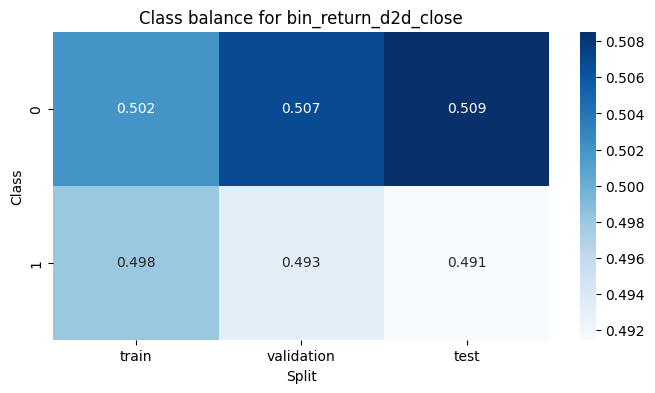

In [11]:
if BINARY_CLASSIFICATION:
    class_balance = pd.DataFrame(
        {
            "train": y_train.value_counts(normalize=True).sort_index(),
            "validation": y_val.value_counts(normalize=True).sort_index(),
            "test": y_test.value_counts(normalize=True).sort_index(),
        }
    ).fillna(0)
    display(class_balance)
    plt.figure(figsize=(8, 4))
    sns.heatmap(class_balance, annot=True, fmt=".3f", cmap="Blues")
    plt.title(f"Class balance for {OUTPUT_VALUE}")
    plt.xlabel("Split")
    plt.ylabel("Class")
    plt.show()
else:
    print("Target statistics on the training split:")
    print(y_train.describe())

In [12]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    directional_accuracy = np.mean((np.asarray(y_pred) > 0) == (np.asarray(y_true) > 0))
    return {
        "MAE": mae,
        "RMSE": rmse,
        "Directional accuracy": directional_accuracy,
    }

In [13]:
print(f"Number of lag features: {len(feature_columns)}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Number of lag features: 240
Training samples: 14780
Validation samples: 3167
Test samples: 3168


## Building and training model

In [14]:
if BINARY_CLASSIFICATION:
    model = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_features=MAX_FEATURES,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )
else:
    model = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_features=MAX_FEATURES,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )

model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [15]:
model.fit(X_train, y_train)
val_pred = model.predict(X_val)

if BINARY_CLASSIFICATION:
    print("Validation classification report")
    print(classification_report(y_val, val_pred))
else:
    print("Validation regression metrics")
    for metric_name, metric_value in regression_metrics(y_val, val_pred).items():
        print(f"{metric_name}: {metric_value:.6f}")

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])
model.fit(X_train_full, y_train_full)
print(f"Refit RandomForest on train + validation samples: {len(X_train_full)}")

Validation classification report
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1605
           1       0.74      0.76      0.75      1562

    accuracy                           0.75      3167
   macro avg       0.75      0.75      0.75      3167
weighted avg       0.75      0.75      0.75      3167

Refit RandomForest on train + validation samples: 17947


## Verifying model

In [16]:
y_pred = model.predict(X_test)

In [17]:
print(y_test.to_numpy()[:10])
print(np.asarray(y_pred)[:10])

[1 0 1 1 0 1 1 0 0 1]
[1 0 1 1 1 1 1 0 1 1]


In [18]:
if BINARY_CLASSIFICATION:
    print(classification_report(y_test, y_pred))
else:
    print("Test regression metrics")
    for metric_name, metric_value in regression_metrics(y_test, y_pred).items():
        print(f"{metric_name}: {metric_value:.6f}")

              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1611
           1       0.74      0.76      0.75      1557

    accuracy                           0.75      3168
   macro avg       0.75      0.75      0.75      3168
weighted avg       0.75      0.75      0.75      3168



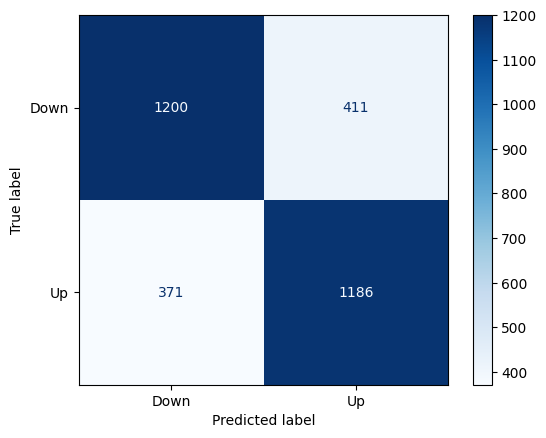

In [19]:
if BINARY_CLASSIFICATION:
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", display_labels=["Down", "Up"])
else:
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test, label="True")
    plt.plot(y_test.index, y_pred, label="Predicted")
    plt.title(f"RandomForest predictions for {OUTPUT_VALUE}")
    plt.xlabel("Date")
    plt.ylabel(OUTPUT_VALUE)
    plt.legend()
    plt.show()

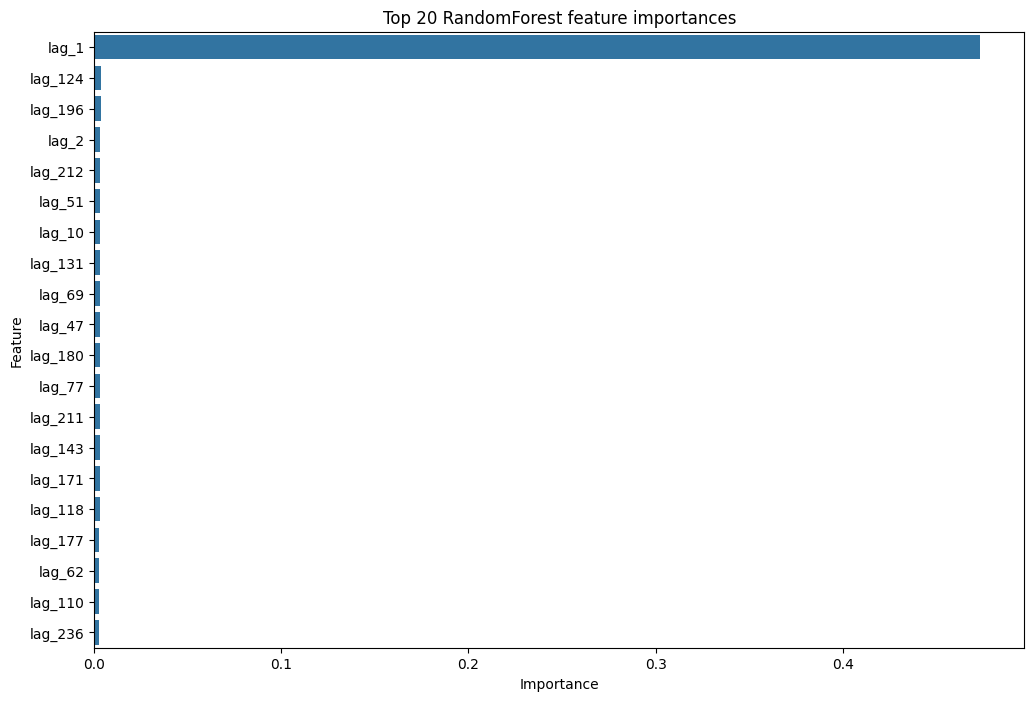

In [20]:
feature_importance = pd.Series(model.feature_importances_, index=X_train_full.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance.head(20).values, y=feature_importance.head(20).index)
plt.title("Top 20 RandomForest feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Backtesting model

Final cash: 803.09
Strategy return: -19.69%
Buy and hold return: -20.34%


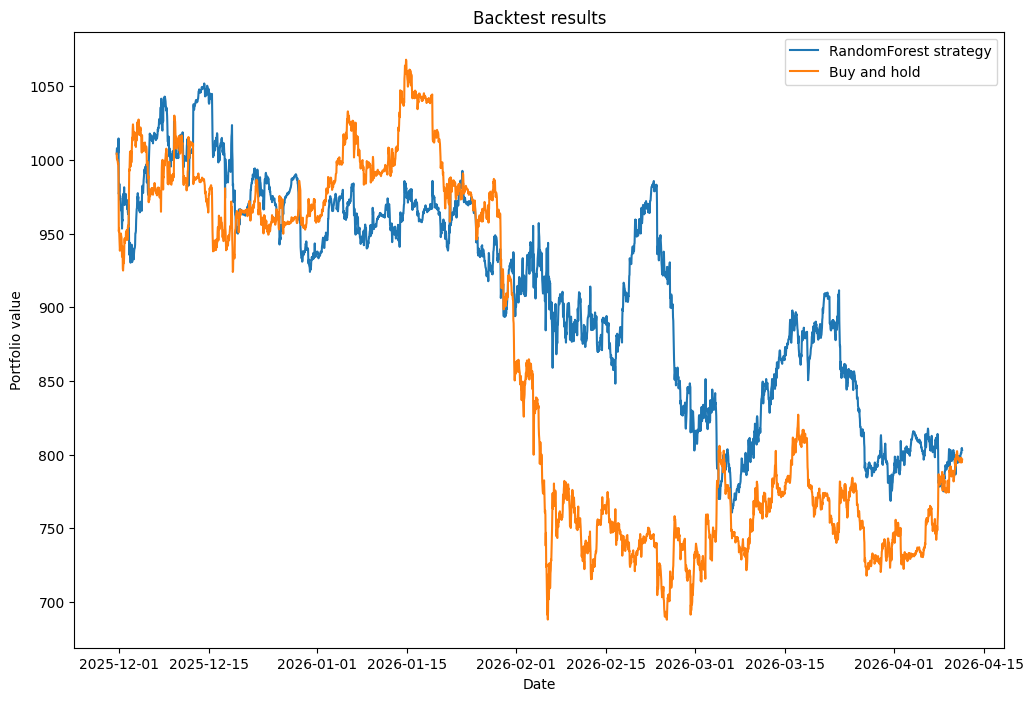

In [21]:
if BINARY_CLASSIFICATION:
    strategy_signal = pd.Series(np.where(np.asarray(y_pred) == 1, 1, -1), index=y_return_test.index)
else:
    strategy_signal = pd.Series(np.where(np.asarray(y_pred) > 0, 1, -1), index=y_return_test.index)

strategy_returns = strategy_signal * y_return_test
start_cash = 1000.0
strategy_curve = start_cash * (1 + strategy_returns).cumprod()
buy_and_hold_curve = start_cash * (1 + y_return_test).cumprod()

print(f"Final cash: {strategy_curve.iloc[-1]:.2f}")
print(f"Strategy return: {(strategy_curve.iloc[-1] / start_cash - 1) * 100:.2f}%")
print(f"Buy and hold return: {(buy_and_hold_curve.iloc[-1] / start_cash - 1) * 100:.2f}%")

plt.figure(figsize=(12, 8))
plt.plot(strategy_curve.index, strategy_curve, label="RandomForest strategy")
plt.plot(buy_and_hold_curve.index, buy_and_hold_curve, label="Buy and hold")
plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.title("Backtest results")
plt.legend()
plt.show()